**Polynomial Regression**
non-linear relationship between the independent features and dependent features

In [5]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
#non-linear data-quadractic equation
#quadratic equation=ax^2 + bx + c
x=6*np.random.rand(100,1)-3 #2-D array of 100 rows and 1 column
y=0.5 * x**2 +1.5*x+ 2 + np.random.rand(100,1)
#y=0.5x^2+1.5x+2+outliers



Text(0, 0.5, 'y dataset')

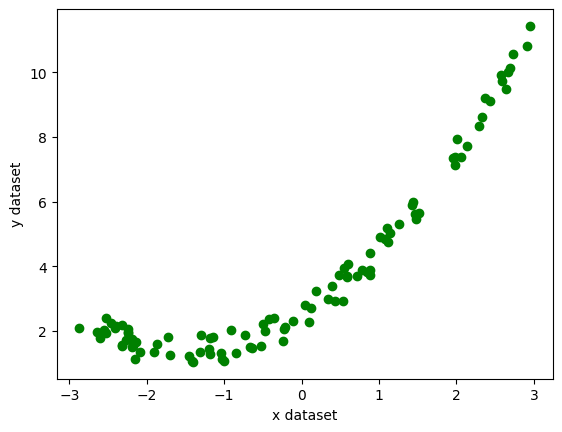

In [8]:
#plot
plt.scatter(x,y,color='green')
plt.xlabel("x dataset")
plt.ylabel("y dataset")

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [11]:
#simple linear regression--learning the relationship between x_train and y_train--learning slope and intercept
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [12]:
#performance of model on the unseen test data--applying the learn slope and intercept to predict the test data
from sklearn.metrics import r2_score
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.7051104652811717

Text(0, 0.5, 'y dataset')

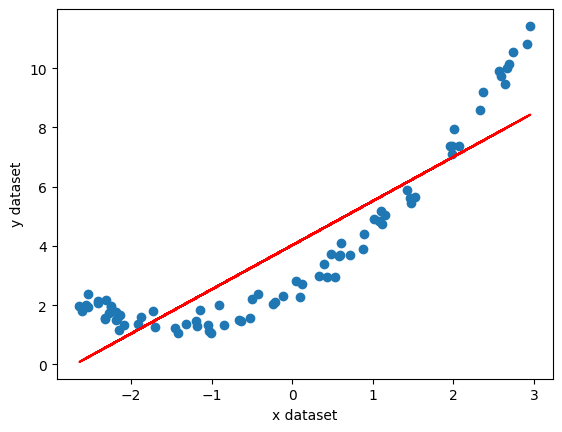

In [14]:
#lets visualize this model--how the best fit line will appear for the training data
plt.plot(x_train,lr.predict(x_train),color='red')
plt.scatter(x_train,y_train)
plt.xlabel("x dataset")
plt.ylabel("y dataset")


As we see that since we have applied the simple linear regression for finding the non-linear relationship among the independent and dependent features, the model is likely to fail and error between the ground truth values and the predicted values would be more (as visible in the plotted red line which signifies the best fit line).To overcome this , we have to apply the polynomial regression to perfectly learn the non-linear relationship between the features so that it can generalise well to the unseen data.

In [15]:
#lets apply polynomial transformation
#degree=2
#y=b+w1x1+w2(x1^2)
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [24]:
x_train_poly.shape


(80, 3)

In [20]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_poly,y_train) #model will learn 3 coefficients(weights)

LinearRegression()

In [27]:
lr.coef_

array([[0.        , 1.4885461 , 0.50567185]])

In [28]:
lr.intercept_

array([2.48918511])

In [29]:
#now performance metrics
from sklearn.metrics import r2_score
y_pred=lr.predict(x_test_poly)
r2_score(y_test,y_pred) #metrics score has increased

0.9792157187624332

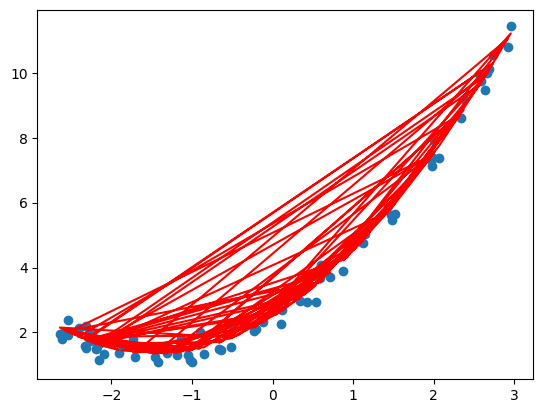

In [56]:
plt.plot(x_train,lr.predict(x_train_poly),color='red')
plt.scatter(x_train,y_train)
plt.show()



In [35]:
#make degree value of input features as 3
poly=PolynomialFeatures(degree=3,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [37]:
x_train_poly.shape

(80, 4)

In [38]:
y_train.shape

(80, 1)

In [36]:
#train model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_poly,y_train)

LinearRegression()

In [39]:
#learnt coefficients and intercepts
lr.coef_

array([[ 0.        ,  1.54457042,  0.50922618, -0.0107516 ]])

In [40]:
#learnt intercept
lr.intercept_

array([2.48242498])

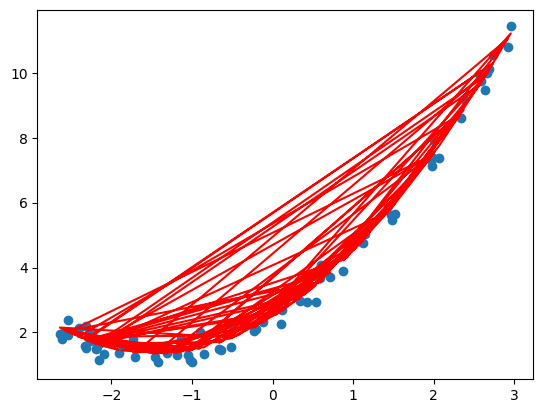

In [51]:
#plotting the fitted line for training data-how it has learnt the training data
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train_poly),color='red')
plt.show()


In [41]:
#now predict
y_pred=lr.predict(x_test_poly)

In [43]:
y_pred.shape

(20, 1)

In [44]:
#check performance metrics--performance decreased
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9778073826122639

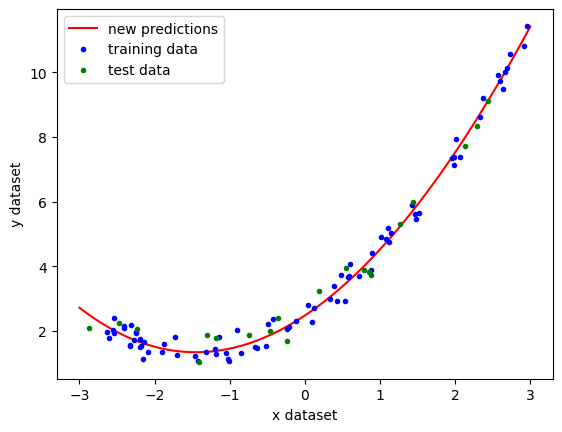

In [54]:
#prediction on new data set
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new) #degree has been set to 3
y_new=lr.predict(x_new_poly)
plt.plot(x_new,y_new,color='red',label='new predictions')
plt.plot(x_train,y_train,'b.',label='training data')
plt.plot(x_test,y_test,'g.',label='test data')
plt.xlabel("x dataset")
plt.ylabel("y dataset")
plt.legend()
plt.show()